# Kinematic figures

Load one recording, slice the figure inputs, define the plotting function,
then run the four figure cells using the project movement environment.

## 1. Set up the DataStructure and load the data

In [1]:
# --- Imports and recording ----------------------------------------------------
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.ticker import MaxNLocator
import movement.kinematics as kin
import numpy as np
import pandas as pd
import xarray as xr
from movement.utils.vector import compute_signed_angle_2d

from data_conduit.datastructures import slice_stream, slice_stream_for_trial
from data_conduit.integrations.DLC.pose import pose_to_movement
from movement_figures.data_template.loading import build_datastructure, prepare_pose
from movement_figures.timeseries_template.annotations import annotate_qc_timeseries

ROOT = Path("/media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training")
session_data = build_datastructure(
    ROOT,
    level_names=("mouseID", "day"),
    l0_selector="MR_M01569515",
    l1_selector="Day21",
    include=("2026-06-21T093349Z",),
    streams=("trials", "events", "dlc"),
)
streams = session_data.load()
session_id = next(iter(session_data.sessions))


                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  


## 2. Calculate measurements and slice the figure inputs

        Coordinates are pixels: x increases to the right, y downwards. Speed uses
        recorded seconds; angular head velocity is signed radians per second.
        Confidence below 0.9 is masked, with no interpolation or smoothing.


Only the selected trial intervals are shown; time between nonadjacent trials stays blank.

In [2]:
# --- Select this recording before calculating derivatives ---------------------
raw_pose = pose_to_movement(
    slice_stream(streams["dlc:position"], selectors={"session": session_id}),
    slice_stream(streams["dlc:confidence"], selectors={"session": session_id}),
)
pose = prepare_pose(raw_pose, confidence_threshold=0.9)  # Leave low-confidence gaps unfilled.
position = pose.position.sel(individual="individual_0", drop=True)
point = position.sel(keypoint="body", drop=True)
point.attrs["units"] = "px"

# --- Calculate on the full recording, so trial cuts do not create derivatives --
linear_speed = kin.compute_speed(point).where(point.notnull().all("space"))
head_direction = kin.compute_head_direction_vector(
    position, left_keypoint="lear", right_keypoint="rear", camera_view="top_down",
)
head_rotation = compute_signed_angle_2d(head_direction.shift(time=1), head_direction)
elapsed_seconds = head_direction.time - head_direction.time.shift(time=1)
measurements = xr.Dataset({
    "x_position": point.sel(space="x", drop=True),
    "y_position": point.sel(space="y", drop=True),
    "linear_speed": linear_speed,
    "angular_head_velocity": head_rotation / elapsed_seconds,
})  # Angular velocity describes the preceding interval; the first value is NaN.
measurements.x_position.attrs["units"] = "px"
measurements.y_position.attrs["units"] = "px"
measurements.linear_speed.attrs["units"] = "px/s"
measurements.angular_head_velocity.attrs["units"] = "rad/s"

# --- Choose the trial IDs shared by the four figures ---------------------------
selected_trials = slice_stream(
    streams["trials"], selectors={"session": session_id, "trial_index": [1, 2, 3]},
)
events = slice_stream(streams["events"], selectors={"session": session_id})

In [3]:
# Keep the exact trial intervals, including their open/closed boundary rules.
keep_samples = xr.zeros_like(measurements.time, dtype=bool)
keep_events = np.zeros(len(events), dtype=bool)
for _, trial in selected_trials.iterrows():
    trial_measurements = slice_stream_for_trial(measurements, trial, time_coord="time")
    trial_events = slice_stream_for_trial(events, trial, time_coord="Time")
    keep_samples = keep_samples | measurements.time.isin(trial_measurements.time)
    keep_events |= events.event_index.isin(trial_events.event_index).to_numpy()

# Mask excluded intervals rather than joining separated trials with a line.
selected_clock = slice_stream(measurements.time, where=keep_samples)
selected_measurements = slice_stream(
    measurements.where(keep_samples),
    start=float(selected_clock.time[0]), end=float(selected_clock.time[-1]),
    time_coord="time",
)
selected_events = slice_stream(events, where=keep_events)
selected_trials

,trial_index,start_time,end_time,start_inclusive,end_inclusive,first_event_index,last_event_index,tz_triggered_time,tz_available_time,ChosenPort,...,outbound_end_time,outbound_start_inclusive,outbound_end_inclusive,inbound_start_time,inbound_end_time,inbound_start_inclusive,inbound_end_inclusive,session,mouseID,day
0,1,5633.836992,5667.029120,True,True,1,12,5663.198976,5640.910976,0,...,5663.198976,True,True,5663.198976,5667.029120,True,True,2026-06-21T093349Z,MR_M01569515,Day21
1,2,5667.029120,5681.075968,False,True,13,27,5678.849984,5675.540992,0,...,5678.849984,False,True,5678.849984,5681.075968,True,True,2026-06-21T093349Z,MR_M01569515,Day21
2,3,5681.075968,5695.245088,False,True,28,42,5693.349984,5690.241984,0,...,5693.349984,False,True,5693.349984,5695.245088,True,True,2026-06-21T093349Z,MR_M01569515,Day21


## 3. Define the figure function

Rows cover equal durations and share one y scale. QC annotations use the
selected trial/event tables. This is a time-series figure, so there is no
video background.

In [4]:
def plot_wrapped_kinematic_trace(
    trace: xr.DataArray,
    trials: pd.DataFrame,
    events: pd.DataFrame | None,
    *,
    row_duration_s: float,
    ylabel: str,
    title: str,
    y_mode: str = "data",
) -> tuple[Figure, np.ndarray]:
    """Plot one selected measurement in consecutive rows of equal duration.

    Parameters
    ----------
    trace : xarray.DataArray
        One-dimensional measurements indexed by session seconds in time.
        Missing measurements and clock gaps remain breaks in the line.
    trials, events : pandas.DataFrame, pandas.DataFrame or None
        Selected trial and event annotations from the same recording as trace.
        trials contains start_time/end_time and QC fields; events uses Time
        and Event. Pass None for events to omit raw event markers.
    row_duration_s : float
        Positive number of seconds displayed across each row.
    ylabel, title : str
        Measurement label including units, and the figure title.
    y_mode : str
        "data" pads the observed range, "nonnegative" starts at zero, and
        "symmetric" centres the range on zero. All rows share this scale.

    Returns
    -------
    figure : matplotlib.figure.Figure
        Figure with QC annotations; display or save it in a later cell.
    axes : numpy.ndarray
        One-dimensional array of row axes for further formatting.
    """
    # --- Shared time and measurement scales -----------------------------------
    times = np.asarray(trace.time.values, dtype=float)
    start, end = times[0], times[-1]
    gap_limit = 5 * np.median(np.diff(times))  # Break lines across missing acquisition intervals.
    finite = trace.values[np.isfinite(trace.values)]
    low, high = (float(finite.min()), float(finite.max())) if finite.size else (0., 1.)
    if y_mode == "symmetric":
        limit = 1.05 * max(abs(low), abs(high), 1e-6)
        y_limits = (-limit, limit)
    elif y_mode == "nonnegative":
        y_limits = (0., 1.05 * max(high, 1.))
    else:
        padding = 0.05 * (high - low) if high > low else 1.
        y_limits = (low - padding, high + padding)

    row_count = max(1, int(np.ceil((end - start) / row_duration_s)))
    figure, grid = plt.subplots(
        row_count, 1, squeeze=False, sharey=True,
        figsize=(14, 2.65 * row_count + 1.1), layout="constrained",
    )
    axes = grid[:, 0]
    legend_handles = {}
    for row_number, ax in enumerate(axes):
        row_start = start + row_number * row_duration_s
        row_stop = row_start + row_duration_s
        selected_stop = min(row_stop, end)
        row_trace = trace.sel(time=slice(row_start, selected_stop))
        row_times = np.asarray(row_trace.time.values, dtype=float)
        row_values = np.asarray(row_trace.values, dtype=float)

        # --- Preserve both measured endpoints around an acquisition gap -------
        gaps = np.flatnonzero(np.diff(row_times) > gap_limit) + 1
        gap_times = (row_times[gaps - 1] + row_times[gaps]) / 2
        ax.plot(
            np.insert(row_times, gaps, gap_times), np.insert(row_values, gaps, np.nan),
            color="#5b4b9a", linewidth=1.15, zorder=3,
        )
        ax.set_ylim(*y_limits)

        # --- Clip the supplied annotations to this drawing row ----------------
        annotations = annotate_qc_timeseries(
            ax, trials, events, window=(row_start, selected_stop), legend=False,
        )
        for handle in annotations.legend_handles:
            legend_handles.setdefault(handle.get_label(), handle)

        # Every row has the same duration, including the unused final tail.
        if selected_stop < row_stop:
            ax.axvspan(selected_stop, row_stop, color="0.94", zorder=0)
        ax.set(xlim=(row_start, row_stop), ylabel=ylabel, xlabel="Session time (s)")
        ax.set_title(f"Row {row_number + 1}", loc="left", fontsize=10, pad=13)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=7))
        ax.ticklabel_format(axis="x", style="plain", useOffset=False)
        ax.grid(axis="y", color="0.9", linewidth=0.6)
        ax.spines[["top", "right"]].set_visible(False)

    # --- One legend for the whole figure --------------------------------------
    figure.suptitle(title, fontsize=15)
    if legend_handles:
        figure.legend(
            list(legend_handles.values()), list(legend_handles),
            loc="outside lower center", ncol=4, fontsize=9, frameon=False,
        )
    return figure, axes

## 4. Create and return the figures

### x position (px)

In [10]:
# x_position_figure, x_position_axes = plot_wrapped_kinematic_trace(
#     selected_measurements["x_position"], selected_trials, selected_events,
#     row_duration_s=25., ylabel="x position (px)",
#     title=f"{session_id} · x position (px)", y_mode="data",
# )
# plt.close(x_position_figure)  # Display the returned figure once below.
# x_position_figure

### y position (px)

In [9]:
# y_position_figure, y_position_axes = plot_wrapped_kinematic_trace(
#     selected_measurements["y_position"], selected_trials, selected_events,
#     row_duration_s=25., ylabel="y position (px)",
#     title=f"{session_id} · y position (px)", y_mode="data",
# )
# plt.close(y_position_figure)  # Display the returned figure once below.
# y_position_figure

### Linear speed (px/s)

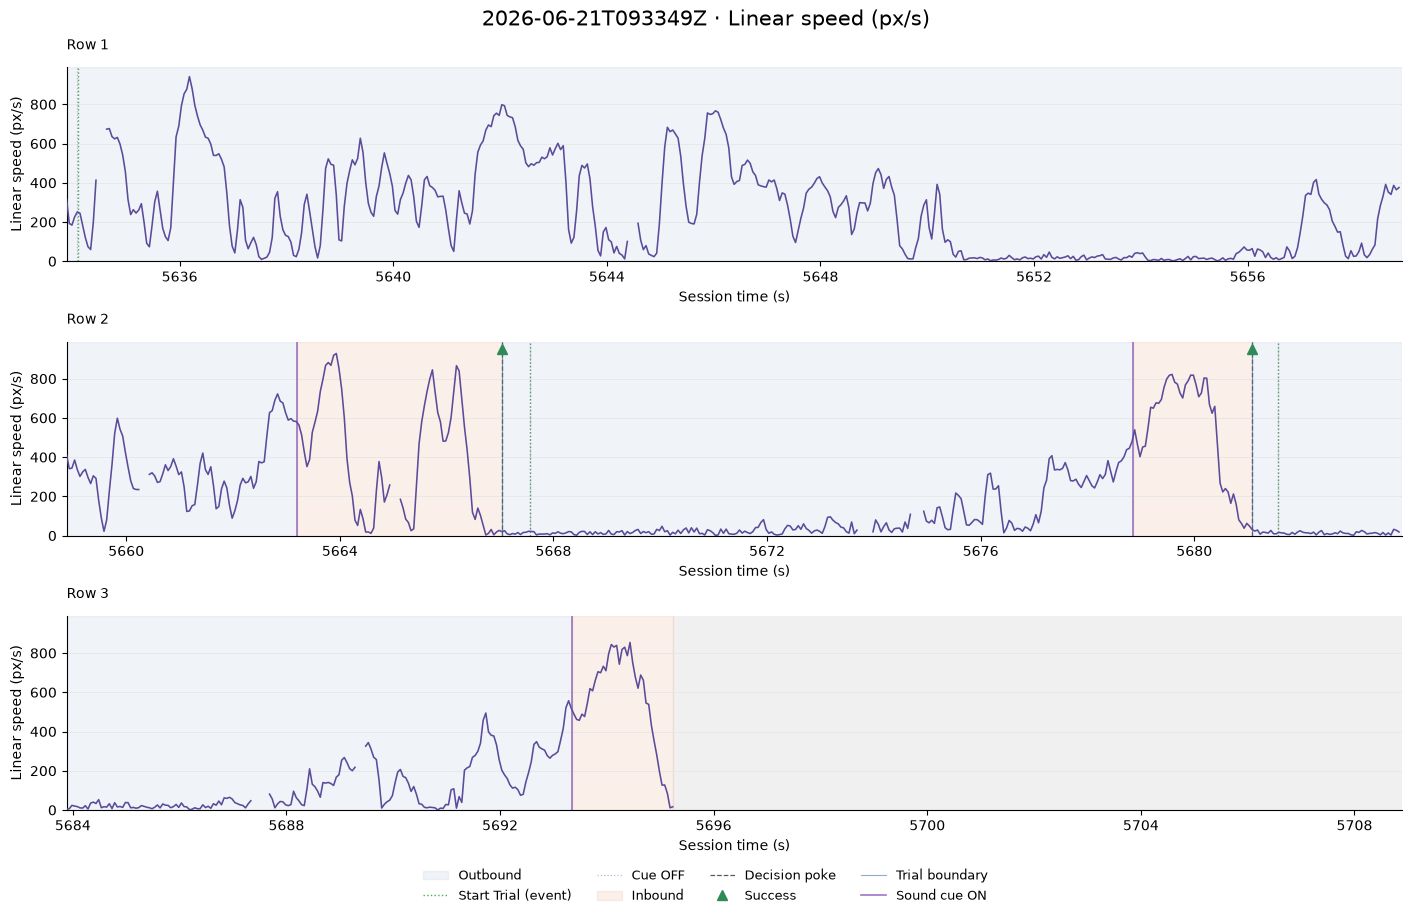

In [7]:
linear_speed_figure, linear_speed_axes = plot_wrapped_kinematic_trace(
    selected_measurements["linear_speed"], selected_trials, selected_events,
    row_duration_s=25., ylabel="Linear speed (px/s)",
    title=f"{session_id} · Linear speed (px/s)", y_mode="nonnegative",
)
plt.close(linear_speed_figure)  # Display the returned figure once below.
linear_speed_figure

### Angular head velocity (rad/s)

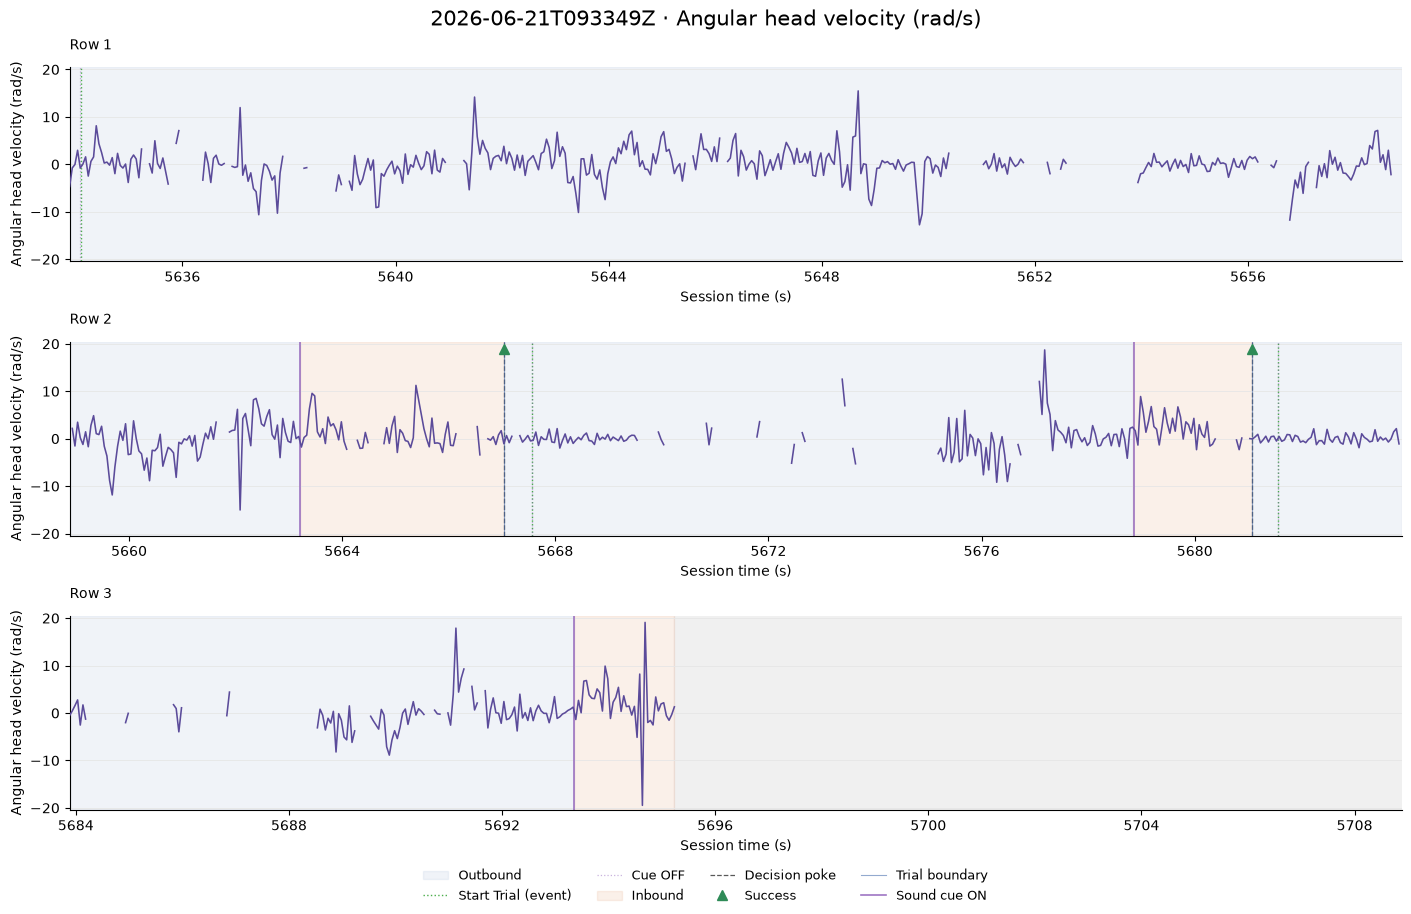

In [8]:
angular_head_velocity_figure, angular_head_velocity_axes = plot_wrapped_kinematic_trace(
    selected_measurements["angular_head_velocity"], selected_trials, selected_events,
    row_duration_s=25., ylabel="Angular head velocity (rad/s)",
    title=f"{session_id} · Angular head velocity (rad/s)", y_mode="symmetric",
)
plt.close(angular_head_velocity_figure)  # Display the returned figure once below.
angular_head_velocity_figure